<a href="https://colab.research.google.com/github/partha-pkp/data-mining-drug-discovery/blob/main/avanie/LOGISTIC_PYTHON.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



LOOCV Logistic Regression with Cost-Sensitive Tuning
====================================================

Purpose
-------
This version focuses on cost-sensitive learning, which is important for this
senolytic problem because the positive class is rare and missing a true
senolytic is costly.

Workflow
--------
1. Upload ARFF data
2. Build logistic regression pipelines
3. Keep regularization fixed at C = 0.1
4. Compare several cost-sensitive class weights
5. Compare feature selection on/off
6. Run Leave-One-Out Cross-Validation (LOOCV) for each configuration
7. Tune the threshold so recall is at least 0.80, then maximize precision
8. Compare ROC curves and PR curves across cost-sensitive settings
9. Save summary tables and plots

Notes
-----
- In scikit-learn logistic regression, class_weight is the main way to do
  cost-sensitive learning.
- A class weight like {0:1, 1:10} means errors on the positive class are
  penalized much more heavily than errors on the negative class.
- This script fixes C=0.1 throughout, as requested.

In [ ]:
!pip -q install liac-arff imbalanced-learn

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from scipy.io import arff

from sklearn.impute import SimpleImputer
from sklearn.model_selection import LeaveOneOut
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    average_precision_score,
    roc_curve,
    roc_auc_score
)

from imblearn.pipeline import Pipeline as ImbPipeline

In [ ]:
# =========================================================
# 1) Upload and load ARFF
# =========================================================
from google.colab import files
from scipy.io import arff
import pandas as pd

uploaded = files.upload()
ARFF_FILE = list(uploaded.keys())[0]

data, meta = arff.loadarff(ARFF_FILE)
df = pd.DataFrame(data)

TARGET_COL = "senolytic"
df[TARGET_COL] = df[TARGET_COL].str.decode("utf-8").astype(int)

X = df.drop(columns=[TARGET_COL]).copy()
y = df[TARGET_COL].copy()

print("Loaded file:", ARFF_FILE)
print("Shape:", df.shape)
print("Positive count:", int(y.sum()))
print("Negative count:", int((y == 0).sum()))
print("Positive rate:", y.mean())

Saving input_data_no_smiles.arff to input_data_no_smiles (2).arff
Loaded file: input_data_no_smiles (2).arff
Shape: (4866, 201)
Positive count: 103
Negative count: 4763
Positive rate: 0.02116728318947801


In [ ]:
# =========================================================
# 2) Helper functions
# =========================================================
def make_feature_selector():
    return SelectFromModel(
        RandomForestClassifier(
            n_estimators=300,
            n_jobs=-1
        ),
        threshold="median"
    )


def make_pipeline(use_feature_selection=True, class_weight=None, C=0.1, max_iter=5000):
    """
    Cost-sensitive learning is implemented here through class_weight.
    """
    steps = [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]

    if use_feature_selection:
        steps.append(("feature_select", make_feature_selector()))

    steps.append((
        "model",
        LogisticRegression(
            C=C,                       # fixed at 0.1
            class_weight=class_weight, # cost-sensitive learning here
            solver="liblinear",
            max_iter=max_iter
        )
    ))

    return ImbPipeline(steps)


def run_loocv_probabilities(X, y, pipeline, verbose_every=250):
    loo = LeaveOneOut()

    y_true_all = []
    y_prob_all = []

    total_folds = len(X)
    for fold_idx, (train_idx, test_idx) in enumerate(loo.split(X), start=1):
        X_train = X.iloc[train_idx]
        X_test  = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test  = y.iloc[test_idx]

        pipeline.fit(X_train, y_train)
        prob = pipeline.predict_proba(X_test)[:, 1][0]

        y_true_all.append(int(y_test.iloc[0]))
        y_prob_all.append(float(prob))

        if fold_idx % verbose_every == 0 or fold_idx == total_folds:
            print(f"Completed fold {fold_idx}/{total_folds}")

    return np.array(y_true_all), np.array(y_prob_all)


def threshold_for_target_recall(y_true, y_prob, target_recall=0.80):
    """
    Select threshold by:
    1) keeping recall >= target_recall
    2) maximizing precision among those thresholds
    """
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)

    precisions_t = precisions[:-1]
    recalls_t = recalls[:-1]

    valid = np.where(recalls_t >= target_recall)[0]
    if len(valid) == 0:
        return None

    best_idx = valid[np.argmax(precisions_t[valid])]
    return {
        "threshold": thresholds[best_idx],
        "precision": precisions_t[best_idx],
        "recall": recalls_t[best_idx]
    }


def evaluate_at_threshold(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "avg_precision": average_precision_score(y_true, y_prob),
        "cm": confusion_matrix(y_true, y_pred),
        "y_pred": y_pred
    }


def plot_all_roc_curves(results, out_path=None):
    plt.figure(figsize=(9, 7))
    for res in results:
        fpr, tpr, _ = roc_curve(res["y_true"], res["y_prob"])
        auc = roc_auc_score(res["y_true"], res["y_prob"])
        plt.plot(fpr, tpr, label=f'{res["name"]} (AUC={auc:.3f})')

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves Across Cost-Sensitive Logistic Models")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True)

    if out_path:
        plt.savefig(out_path, bbox_inches="tight", dpi=300)

    plt.show()


def plot_all_pr_curves(results, out_path=None):
    plt.figure(figsize=(9, 7))
    for res in results:
        precisions, recalls, _ = precision_recall_curve(res["y_true"], res["y_prob"])
        ap = average_precision_score(res["y_true"], res["y_prob"])
        plt.plot(recalls, precisions, label=f'{res["name"]} (AP={ap:.3f})')

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curves Across Cost-Sensitive Logistic Models")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True)

    if out_path:
        plt.savefig(out_path, bbox_inches="tight", dpi=300)

    plt.show()


def plot_best_pr_with_threshold(best_result, out_path=None):
    y_true = best_result["y_true"]
    y_prob = best_result["y_prob"]
    threshold = best_result["chosen_threshold"]

    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)

    plt.figure(figsize=(8, 6))
    plt.plot(recalls, precisions, label=best_result["name"])

    if threshold is not None and len(thresholds) > 0:
        idx = np.argmin(np.abs(thresholds - threshold))
        idx = min(idx, len(precisions) - 2)
        plt.scatter(recalls[idx], precisions[idx], s=100, label=f"Threshold={threshold:.4f}")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Best Model PR Curve with Chosen Threshold")
    plt.legend()
    plt.grid(True)

    if out_path:
        plt.savefig(out_path, bbox_inches="tight", dpi=300)

    plt.show()


def plot_confusion(y_true, y_pred, title, normalize=None, out_path=None):
    cm = confusion_matrix(y_true, y_pred, normalize=normalize)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non-Senolytic", "Senolytic"]
    )

    plt.figure(figsize=(6, 6))
    disp.plot(cmap="Blues", values_format=".2f" if normalize else "d")
    plt.title(title)

    if out_path:
        plt.savefig(out_path, bbox_inches="tight", dpi=300)

    plt.show()

In [ ]:
# =========================================================
# 3) Parameter grid
# =========================================================
# Faster workflow:
# Phase 1: compare cost-sensitive weights WITHOUT feature selection
# Phase 2: compare feature selection ON vs OFF for one strong weight
# C stays fixed at 0.1

TARGET_RECALL = 0.80
FIXED_C = 0.1

PARAM_GRID = [
    {
        "name": "noFS_weight_none",
        "use_feature_selection": False,
        "class_weight": None,
        "C": FIXED_C
    },
    {
        "name": "noFS_weight_balanced",
        "use_feature_selection": False,
        "class_weight": "balanced",
        "C": FIXED_C
    },
    {
        "name": "noFS_weight_pos5",
        "use_feature_selection": False,
        "class_weight": {0: 1, 1: 5},
        "C": FIXED_C
    },
    {
        "name": "noFS_weight_pos10",
        "use_feature_selection": False,
        "class_weight": {0: 1, 1: 10},
        "C": FIXED_C
    },
    {
        "name": "noFS_weight_pos20",
        "use_feature_selection": False,
        "class_weight": {0: 1, 1: 20},
        "C": FIXED_C
    },

    # Focused feature selection comparison
    {
        "name": "FS_weight_pos10",
        "use_feature_selection": True,
        "class_weight": {0: 1, 1: 10},
        "C": FIXED_C
    }
]

print("\nFixed regularization C:", FIXED_C)
print("Target recall:", TARGET_RECALL)
print("\nParameter grid:")
for cfg in PARAM_GRID:
    print(cfg)


Fixed regularization C: 0.1
Target recall: 0.8

Parameter grid:
{'name': 'noFS_weight_none', 'use_feature_selection': False, 'class_weight': None, 'C': 0.1}
{'name': 'noFS_weight_balanced', 'use_feature_selection': False, 'class_weight': 'balanced', 'C': 0.1}
{'name': 'noFS_weight_pos5', 'use_feature_selection': False, 'class_weight': {0: 1, 1: 5}, 'C': 0.1}
{'name': 'noFS_weight_pos10', 'use_feature_selection': False, 'class_weight': {0: 1, 1: 10}, 'C': 0.1}
{'name': 'noFS_weight_pos20', 'use_feature_selection': False, 'class_weight': {0: 1, 1: 20}, 'C': 0.1}
{'name': 'FS_weight_pos10', 'use_feature_selection': True, 'class_weight': {0: 1, 1: 10}, 'C': 0.1}


In [ ]:
# =========================================================
# 5) Run LOOCV for each cost-sensitive setting (STAGED)
# =========================================================

all_results = []

total_models = len(PARAM_GRID)
overall_start = time.time()

for i, cfg in enumerate(PARAM_GRID, start=1):
    model_start = time.time()

    print("\n" + "=" * 80)
    print(f"Running model {i}/{total_models}: {cfg['name']}")
    print(f"Class weight: {cfg['class_weight']}")
    print(f"Feature selection: {cfg['use_feature_selection']}")

    if cfg["use_feature_selection"]:
        print("Phase: Feature Selection comparison")
    else:
        print("Phase: Weight tuning (no feature selection)")

    print("=" * 80)

    # -------------------------------
    # Build pipeline
    # -------------------------------
    pipe = make_pipeline(
        use_feature_selection=cfg["use_feature_selection"],
        class_weight=cfg["class_weight"],
        C=cfg["C"]
    )

    # -------------------------------
    # Run LOOCV
    # -------------------------------
    print(f">>> Starting LOOCV for model: {cfg['name']}")

    y_true_oof, y_prob_oof = run_loocv_probabilities(
        X,
        y,
        pipe,
        25
    )

    print(f">>> Finished LOOCV for {cfg['name']}")

    # -------------------------------
    # Evaluate default threshold
    # -------------------------------
    default_metrics = evaluate_at_threshold(
        y_true=y_true_oof,
        y_prob=y_prob_oof,
        threshold=0.5
    )

    # -------------------------------
    # Tune threshold: recall >= target, then maximize precision
    # -------------------------------
    tuned = threshold_for_target_recall(
        y_true=y_true_oof,
        y_prob=y_prob_oof,
        target_recall=TARGET_RECALL
    )

    if tuned is None:
        chosen_threshold = 0.5
        print("No threshold achieved the recall target. Using default threshold = 0.5")
    else:
        chosen_threshold = tuned["threshold"]

    tuned_metrics = evaluate_at_threshold(
        y_true=y_true_oof,
        y_prob=y_prob_oof,
        threshold=chosen_threshold
    )

    # -------------------------------
    # Store results
    # -------------------------------
    result = {
        "name": cfg["name"],
        "config": cfg,
        "y_true": y_true_oof,
        "y_prob": y_prob_oof,
        "default_metrics": default_metrics,
        "tuned_metrics": tuned_metrics,
        "chosen_threshold": chosen_threshold
    }
    all_results.append(result)

    # -------------------------------
    # Print results
    # -------------------------------
    print("\n--- Default Threshold (0.5) ---")
    print(f"Threshold : 0.500000")
    print(f"Precision : {default_metrics['precision']:.4f}")
    print(f"Recall    : {default_metrics['recall']:.4f}")
    print(f"F1        : {default_metrics['f1']:.4f}")
    print(f"ROC-AUC   : {default_metrics['roc_auc']:.4f}")
    print(f"AP        : {default_metrics['avg_precision']:.4f}")

    print("\n--- Tuned Threshold ---")
    print(f"Threshold : {chosen_threshold:.6f}")
    print(f"Precision : {tuned_metrics['precision']:.4f}")
    print(f"Recall    : {tuned_metrics['recall']:.4f}")
    print(f"F1        : {tuned_metrics['f1']:.4f}")
    print(f"ROC-AUC   : {tuned_metrics['roc_auc']:.4f}")
    print(f"AP        : {tuned_metrics['avg_precision']:.4f}")

    print("\nConfusion Matrix:")
    print(tuned_metrics["cm"])

    # -------------------------------
    # Timing
    # -------------------------------
    model_time = (time.time() - model_start) / 60
    print(f"\nModel runtime: {model_time:.2f} minutes")

# -------------------------------
# Total runtime
# -------------------------------
total_time = (time.time() - overall_start) / 60
print("\n" + "=" * 80)
print(f"ALL MODELS COMPLETE in {total_time:.2f} minutes")
print("=" * 80)


Running model 1/6: noFS_weight_none
Class weight: None
Feature selection: False
Phase: Weight tuning (no feature selection)
>>> Starting LOOCV for model: noFS_weight_none
Completed fold 25/4866
Completed fold 50/4866
Completed fold 75/4866
Completed fold 100/4866
Completed fold 125/4866
Completed fold 150/4866
Completed fold 175/4866
Completed fold 200/4866
Completed fold 225/4866
Completed fold 250/4866
Completed fold 275/4866
Completed fold 300/4866
Completed fold 325/4866
Completed fold 350/4866
Completed fold 375/4866
Completed fold 400/4866
Completed fold 425/4866
Completed fold 450/4866
Completed fold 475/4866
Completed fold 500/4866
Completed fold 525/4866
Completed fold 550/4866
Completed fold 575/4866
Completed fold 600/4866
Completed fold 625/4866
Completed fold 650/4866
Completed fold 675/4866
Completed fold 700/4866
Completed fold 725/4866
Completed fold 750/4866
Completed fold 775/4866
Completed fold 800/4866
Completed fold 825/4866
Completed fold 850/4866
Completed fold 

In [ ]:
# =========================================================
# RECOVERY: helper functions (DO NOT rerun models)
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    precision_recall_curve, roc_curve, ConfusionMatrixDisplay
)

from imblearn.pipeline import Pipeline as ImbPipeline


# -------------------------------
# Feature selector
# -------------------------------
def make_feature_selector():
    return SelectFromModel(
        RandomForestClassifier(
            n_estimators=300,
            n_jobs=-1
        ),
        threshold="median"
    )


# -------------------------------
# Pipeline
# -------------------------------
def make_pipeline(use_feature_selection=True, class_weight=None, C=0.1, max_iter=5000):
    steps = [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]

    if use_feature_selection:
        steps.append(("feature_select", make_feature_selector()))

    steps.append((
        "model",
        LogisticRegression(
            C=C,
            class_weight=class_weight,
            solver="liblinear",
            max_iter=max_iter
        )
    ))

    return ImbPipeline(steps)


# -------------------------------
# LOOCV
# -------------------------------
def run_loocv_probabilities(X, y, pipeline, verbose_every=250):
    loo = LeaveOneOut()

    y_true_all = []
    y_prob_all = []

    total_folds = len(X)

    for fold_idx, (train_idx, test_idx) in enumerate(loo.split(X), start=1):
        X_train = X.iloc[train_idx]
        X_test  = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test  = y.iloc[test_idx]

        pipeline.fit(X_train, y_train)
        prob = pipeline.predict_proba(X_test)[:, 1][0]

        y_true_all.append(int(y_test.iloc[0]))
        y_prob_all.append(float(prob))

        if fold_idx % verbose_every == 0 or fold_idx == total_folds:
            print(f"Completed fold {fold_idx}/{total_folds}")

    return np.array(y_true_all), np.array(y_prob_all)


# -------------------------------
# Threshold selection
# -------------------------------
def threshold_for_target_recall(y_true, y_prob, target_recall=0.80):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)

    precisions_t = precisions[:-1]
    recalls_t = recalls[:-1]

    valid = np.where(recalls_t >= target_recall)[0]
    if len(valid) == 0:
        return None

    best_idx = valid[np.argmax(precisions_t[valid])]
    return {
        "threshold": thresholds[best_idx],
        "precision": precisions_t[best_idx],
        "recall": recalls_t[best_idx]
    }


# -------------------------------
# Evaluation
# -------------------------------
def evaluate_at_threshold(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "avg_precision": average_precision_score(y_true, y_prob),
        "cm": confusion_matrix(y_true, y_pred),
        "y_pred": y_pred
    }

In [ ]:
print(make_pipeline)
print(run_loocv_probabilities)
print(threshold_for_target_recall)
print(evaluate_at_threshold)

<function make_pipeline at 0x7c6bdb137ce0>
<function run_loocv_probabilities at 0x7c6c1a1a3d80>
<function threshold_for_target_recall at 0x7c6bdb137e20>
<function evaluate_at_threshold at 0x7c6bda4c8b80>


In [ ]:
# =========================================================
# FULL RECOVERY BLOCK: load data + helper functions + FS runs
# =========================================================

# -------------------------------
# 1) Imports
# -------------------------------
from google.colab import files
from scipy.io import arff
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    precision_recall_curve, roc_curve, ConfusionMatrixDisplay
)

from imblearn.pipeline import Pipeline as ImbPipeline


# -------------------------------
# 2) Upload and load ARFF
# -------------------------------
uploaded = files.upload()
ARFF_FILE = list(uploaded.keys())[0]

data, meta = arff.loadarff(ARFF_FILE)
df = pd.DataFrame(data)

TARGET_COL = "senolytic"
df[TARGET_COL] = df[TARGET_COL].str.decode("utf-8").astype(int)

X = df.drop(columns=[TARGET_COL]).copy()
y = df[TARGET_COL].copy()

print("Loaded file:", ARFF_FILE)
print("Shape:", df.shape)
print("Positive count:", int(y.sum()))
print("Negative count:", int((y == 0).sum()))
print("Positive rate:", y.mean())


# -------------------------------
# 3) Constants
# -------------------------------
TARGET_RECALL = 0.80
FIXED_C = 0.1

# Since Colab wiped memory, start fresh
all_results = []


# -------------------------------
# 4) Helper functions
# -------------------------------
def make_feature_selector():
    return SelectFromModel(
        RandomForestClassifier(
            n_estimators=300,
            n_jobs=-1
        ),
        threshold="median"
    )


def make_pipeline(use_feature_selection=True, class_weight=None, C=0.1, max_iter=5000):
    """
    Cost-sensitive learning is implemented here through class_weight.
    """
    steps = [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]

    if use_feature_selection:
        steps.append(("feature_select", make_feature_selector()))

    steps.append((
        "model",
        LogisticRegression(
            C=C,
            class_weight=class_weight,
            solver="liblinear",
            max_iter=max_iter
        )
    ))

    return ImbPipeline(steps)


def run_loocv_probabilities(X, y, pipeline, verbose_every=250):
    loo = LeaveOneOut()

    y_true_all = []
    y_prob_all = []

    total_folds = len(X)
    for fold_idx, (train_idx, test_idx) in enumerate(loo.split(X), start=1):
        X_train = X.iloc[train_idx]
        X_test  = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test  = y.iloc[test_idx]

        pipeline.fit(X_train, y_train)
        prob = pipeline.predict_proba(X_test)[:, 1][0]

        y_true_all.append(int(y_test.iloc[0]))
        y_prob_all.append(float(prob))

        if fold_idx % verbose_every == 0 or fold_idx == total_folds:
            print(f"Completed fold {fold_idx}/{total_folds}")

    return np.array(y_true_all), np.array(y_prob_all)


def threshold_for_target_recall(y_true, y_prob, target_recall=0.80):
    """
    Select threshold by:
    1) keeping recall >= target_recall
    2) maximizing precision among those thresholds
    """
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)

    precisions_t = precisions[:-1]
    recalls_t = recalls[:-1]

    valid = np.where(recalls_t >= target_recall)[0]
    if len(valid) == 0:
        return None

    best_idx = valid[np.argmax(precisions_t[valid])]
    return {
        "threshold": thresholds[best_idx],
        "precision": precisions_t[best_idx],
        "recall": recalls_t[best_idx]
    }


def evaluate_at_threshold(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "avg_precision": average_precision_score(y_true, y_prob),
        "cm": confusion_matrix(y_true, y_pred),
        "y_pred": y_pred
    }


def plot_all_roc_curves(results, out_path=None):
    plt.figure(figsize=(9, 7))
    for res in results:
        fpr, tpr, _ = roc_curve(res["y_true"], res["y_prob"])
        auc = roc_auc_score(res["y_true"], res["y_prob"])
        plt.plot(fpr, tpr, label=f'{res["name"]} (AUC={auc:.3f})')

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves Across Cost-Sensitive Logistic Models")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True)

    if out_path:
        plt.savefig(out_path, bbox_inches="tight", dpi=300)

    plt.show()


def plot_all_pr_curves(results, out_path=None):
    plt.figure(figsize=(9, 7))
    for res in results:
        precisions, recalls, _ = precision_recall_curve(res["y_true"], res["y_prob"])
        ap = average_precision_score(res["y_true"], res["y_prob"])
        plt.plot(recalls, precisions, label=f'{res["name"]} (AP={ap:.3f})')

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curves Across Cost-Sensitive Logistic Models")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True)

    if out_path:
        plt.savefig(out_path, bbox_inches="tight", dpi=300)

    plt.show()


def plot_best_pr_with_threshold(best_result, out_path=None):
    y_true = best_result["y_true"]
    y_prob = best_result["y_prob"]
    threshold = best_result["chosen_threshold"]

    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)

    plt.figure(figsize=(8, 6))
    plt.plot(recalls, precisions, label=best_result["name"])

    if threshold is not None and len(thresholds) > 0:
        idx = np.argmin(np.abs(thresholds - threshold))
        idx = min(idx, len(precisions) - 2)
        plt.scatter(recalls[idx], precisions[idx], s=100, label=f"Threshold={threshold:.4f}")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Best Model PR Curve with Chosen Threshold")
    plt.legend()
    plt.grid(True)

    if out_path:
        plt.savefig(out_path, bbox_inches="tight", dpi=300)

    plt.show()


def plot_confusion(y_true, y_pred, title, normalize=None, out_path=None):
    cm = confusion_matrix(y_true, y_pred, normalize=normalize)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non-Senolytic", "Senolytic"]
    )

    plt.figure(figsize=(6, 6))
    disp.plot(cmap="Blues", values_format=".2f" if normalize else "d")
    plt.title(title)

    if out_path:
        plt.savefig(out_path, bbox_inches="tight", dpi=300)

    plt.show()


# -------------------------------
# 5) Run ONLY the two FS models
# -------------------------------
fs_configs = [
    {
        "name": "FS_weight_balanced",
        "use_feature_selection": True,
        "class_weight": "balanced",
        "C": FIXED_C
    },
    {
        "name": "FS_weight_pos5",
        "use_feature_selection": True,
        "class_weight": {0: 1, 1: 5},
        "C": FIXED_C
    }
]

fs_results = []

for cfg in fs_configs:
    print("\n" + "=" * 80)
    print(f"Running model: {cfg['name']}")
    print(f"Class weight: {cfg['class_weight']}")
    print(f"Feature selection: {cfg['use_feature_selection']}")
    print("=" * 80)

    pipeline = make_pipeline(
        use_feature_selection=cfg["use_feature_selection"],
        class_weight=cfg["class_weight"],
        C=cfg["C"],
        max_iter=5000
    )

    y_true_oof, y_prob_oof = run_loocv_probabilities(
        X=X,
        y=y,
        pipeline=pipeline,
        verbose_every=25
    )

    chosen = threshold_for_target_recall(
        y_true_oof,
        y_prob_oof,
        target_recall=TARGET_RECALL
    )

    if chosen is None:
        print(f"No threshold achieved recall >= {TARGET_RECALL:.2f} for {cfg['name']}")
        chosen_threshold = 0.5
        tuned_metrics = evaluate_at_threshold(y_true_oof, y_prob_oof, chosen_threshold)
    else:
        chosen_threshold = chosen["threshold"]
        tuned_metrics = evaluate_at_threshold(y_true_oof, y_prob_oof, chosen_threshold)

    result = {
        "name": cfg["name"],
        "config": cfg,
        "y_true": y_true_oof,
        "y_prob": y_prob_oof,
        "chosen_threshold": chosen_threshold,
        "tuned_metrics": tuned_metrics
    }

    fs_results.append(result)

    print(f"\nFinished {cfg['name']}")
    print(f"Chosen threshold: {chosen_threshold:.6f}")
    print(f"Precision: {tuned_metrics['precision']:.4f}")
    print(f"Recall:    {tuned_metrics['recall']:.4f}")
    print(f"F1:        {tuned_metrics['f1']:.4f}")
    print(f"ROC-AUC:   {tuned_metrics['roc_auc']:.4f}")
    print(f"AP:        {tuned_metrics['avg_precision']:.4f}")
    print("Confusion Matrix:")
    print(tuned_metrics["cm"])


# -------------------------------
# 6) Store results
# -------------------------------
all_results.extend(fs_results)

print("\nFinished running feature selection models.")
print("Added to all_results:")
for r in fs_results:
    print("-", r["name"])

Saving input_data_no_smiles.arff to input_data_no_smiles (1).arff
Loaded file: input_data_no_smiles (1).arff
Shape: (4866, 201)
Positive count: 103
Negative count: 4763
Positive rate: 0.02116728318947801

Running model: FS_weight_balanced
Class weight: balanced
Feature selection: True
Completed fold 25/4866
Completed fold 50/4866
Completed fold 75/4866
Completed fold 100/4866
Completed fold 125/4866
Completed fold 150/4866
Completed fold 175/4866
Completed fold 200/4866
Completed fold 225/4866
Completed fold 250/4866
Completed fold 275/4866
Completed fold 300/4866
Completed fold 325/4866
Completed fold 350/4866
Completed fold 375/4866
Completed fold 400/4866
Completed fold 425/4866
Completed fold 450/4866
Completed fold 475/4866
Completed fold 500/4866
Completed fold 525/4866
Completed fold 550/4866
Completed fold 575/4866
Completed fold 600/4866
Completed fold 625/4866
Completed fold 650/4866
Completed fold 675/4866
Completed fold 700/4866
Completed fold 725/4866
Completed fold 750/48

In [ ]:
# -------------------------------
# Reload data (ARFF)
# -------------------------------
from google.colab import files
from scipy.io import arff
import pandas as pd

uploaded = files.upload()
ARFF_FILE = list(uploaded.keys())[0]

data, meta = arff.loadarff(ARFF_FILE)
df = pd.DataFrame(data)

TARGET_COL = "senolytic"
df[TARGET_COL] = df[TARGET_COL].str.decode("utf-8").astype(int)

X = df.drop(columns=[TARGET_COL]).copy()
y = df[TARGET_COL].copy()

print("Data loaded:")
print("Shape:", df.shape)
print("Positive rate:", y.mean())
# =========================================================
# SINGLE RUN: FS_weight_pos5 (SELF-CONTAINED)
# =========================================================

# -------------------------------
# Imports (fresh)
# -------------------------------
import time
import numpy as np

from sklearn.model_selection import LeaveOneOut
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve
)

from sklearn.pipeline import Pipeline as ImbPipeline

# -------------------------------
# Helper functions (fresh)
# -------------------------------
def make_feature_selector():
    return SelectFromModel(
        RandomForestClassifier(
            n_estimators=100,  # 🔥 reduced from 300 → faster
            n_jobs=-1
        ),
        threshold="median"
    )

def make_pipeline(use_feature_selection=False, class_weight=None, C=0.1):
    steps = [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]

    if use_feature_selection:
        steps.append(("feature_select", make_feature_selector()))

    steps.append((
        "model",
        LogisticRegression(
            C=C,
            class_weight=class_weight,
            solver="liblinear",
            max_iter=5000
        )
    ))

    return ImbPipeline(steps)

def run_loocv_probabilities(X, y, pipeline, verbose_every=25):
    loo = LeaveOneOut()

    y_true_all = []
    y_prob_all = []

    total_folds = len(X)
    start_time = time.time()

    print(f"\nStarting LOOCV ({total_folds} folds)")

    for fold_idx, (train_idx, test_idx) in enumerate(loo.split(X), start=1):
        X_train = X.iloc[train_idx]
        X_test  = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test  = y.iloc[test_idx]

        pipeline.fit(X_train, y_train)
        prob = pipeline.predict_proba(X_test)[:, 1][0]

        y_true_all.append(int(y_test.iloc[0]))
        y_prob_all.append(float(prob))

        if fold_idx % verbose_every == 0:
            elapsed = time.time() - start_time
            print(f"Fold {fold_idx}/{total_folds} | Elapsed: {elapsed/60:.1f} min")

    print("Finished LOOCV\n")
    return np.array(y_true_all), np.array(y_prob_all)

def evaluate_at_threshold(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "avg_precision": average_precision_score(y_true, y_prob),
        "cm": confusion_matrix(y_true, y_pred)
    }

def threshold_for_target_recall(y_true, y_prob, target_recall=0.80):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)

    precisions = precisions[:-1]
    recalls = recalls[:-1]

    valid = np.where(recalls >= target_recall)[0]
    if len(valid) == 0:
        return None

    best_idx = valid[np.argmax(precisions[valid])]
    return thresholds[best_idx]

# -------------------------------
# Model config
# -------------------------------
TARGET_RECALL = 0.80

cfg = {
    "name": "FS_weight_pos5",
    "use_feature_selection": True,
    "class_weight": {0: 1, 1: 5},
    "C": 0.1
}

# -------------------------------
# Run
# -------------------------------
start_time = time.time()

print("\n" + "=" * 80)
print(f"Running: {cfg['name']}")
print("=" * 80)

pipe = make_pipeline(
    use_feature_selection=cfg["use_feature_selection"],
    class_weight=cfg["class_weight"],
    C=cfg["C"]
)

y_true_oof, y_prob_oof = run_loocv_probabilities(X, y, pipe, verbose_every=25)

# -------------------------------
# Evaluate
# -------------------------------
default_metrics = evaluate_at_threshold(y_true_oof, y_prob_oof, 0.5)

threshold = threshold_for_target_recall(
    y_true_oof,
    y_prob_oof,
    TARGET_RECALL
)

if threshold is None:
    threshold = 0.5
    print("No threshold met recall target, using 0.5")

tuned_metrics = evaluate_at_threshold(y_true_oof, y_prob_oof, threshold)

# -------------------------------
# Results
# -------------------------------
print("\n--- Default Threshold ---")
print(default_metrics)

print("\n--- Tuned Threshold ---")
print(f"Threshold: {threshold:.6f}")
print(tuned_metrics)

# -------------------------------
# Runtime
# -------------------------------
total_time = (time.time() - start_time) / 60
print(f"\n⏱️ Total runtime: {total_time:.2f} minutes")

Saving input_data_no_smiles.arff to input_data_no_smiles.arff
Data loaded:
Shape: (4866, 201)
Positive rate: 0.02116728318947801

Running: FS_weight_pos5

Starting LOOCV (4866 folds)
Fold 25/4866 | Elapsed: 1.2 min
Fold 50/4866 | Elapsed: 2.4 min
Fold 75/4866 | Elapsed: 3.6 min
Fold 100/4866 | Elapsed: 4.8 min
Fold 125/4866 | Elapsed: 6.0 min
Fold 150/4866 | Elapsed: 7.2 min
Fold 175/4866 | Elapsed: 8.4 min
Fold 200/4866 | Elapsed: 9.6 min
Fold 225/4866 | Elapsed: 10.8 min
Fold 250/4866 | Elapsed: 12.0 min
Fold 275/4866 | Elapsed: 13.2 min
Fold 300/4866 | Elapsed: 14.4 min
Fold 325/4866 | Elapsed: 15.6 min
Fold 350/4866 | Elapsed: 16.8 min
Fold 375/4866 | Elapsed: 18.0 min
Fold 400/4866 | Elapsed: 19.2 min
Fold 425/4866 | Elapsed: 20.4 min
Fold 450/4866 | Elapsed: 21.6 min
Fold 475/4866 | Elapsed: 22.8 min
Fold 500/4866 | Elapsed: 24.0 min
Fold 525/4866 | Elapsed: 25.2 min
Fold 550/4866 | Elapsed: 26.4 min
Fold 575/4866 | Elapsed: 27.5 min
Fold 600/4866 | Elapsed: 28.7 min
Fold 625/486

In [ ]:
# =========================================================
# A) RECOVER SUMMARY TABLE FROM FINISHED RUNS
# =========================================================

import numpy as np
import pandas as pd

summary_rows = [
    {
        "model": "noFS_weight_none",
        "feature_selection": False,
        "class_weight": "None",
        "threshold": 0.015807,
        "precision": 0.0335,
        "recall": 0.8058,
        "f1": 0.0643,
        "roc_auc": 0.7708,
        "avg_precision": 0.2132,
        "tn": 2369, "fp": 2394, "fn": 20, "tp": 83
    },
    {
        "model": "noFS_weight_balanced",
        "feature_selection": False,
        "class_weight": "balanced",
        "threshold": 0.156214,
        "precision": 0.0400,
        "recall": 0.8058,
        "f1": 0.0762,
        "roc_auc": 0.7655,
        "avg_precision": 0.0944,
        "tn": 2771, "fp": 1992, "fn": 20, "tp": 83
    },
    {
        "model": "noFS_weight_pos5",
        "feature_selection": False,
        "class_weight": "{0:1,1:5}",
        "threshold": 0.036091,
        "precision": 0.0363,
        "recall": 0.8058,
        "f1": 0.0695,
        "roc_auc": 0.7716,
        "avg_precision": 0.1388,
        "tn": 2561, "fp": 2202, "fn": 20, "tp": 83
    },
    {
        "model": "noFS_weight_pos10",
        "feature_selection": False,
        "class_weight": "{0:1,1:10}",
        "threshold": 0.047964,
        "precision": 0.0347,
        "recall": 0.8058,
        "f1": 0.0666,
        "roc_auc": 0.7692,
        "avg_precision": 0.1199,
        "tn": 2457, "fp": 2306, "fn": 20, "tp": 83
    },
    {
        "model": "noFS_weight_pos20",
        "feature_selection": False,
        "class_weight": "{0:1,1:20}",
        "threshold": 0.064669,
        "precision": 0.0348,
        "recall": 0.8155,
        "f1": 0.0668,
        "roc_auc": 0.7667,
        "avg_precision": 0.1055,
        "tn": 2434, "fp": 2329, "fn": 19, "tp": 84
    },
    {
        "model": "FS_weight_balanced",
        "feature_selection": True,
        "class_weight": "balanced",
        "threshold": 0.232512,
        "precision": 0.0376,
        "recall": 0.8155,
        "f1": 0.0719,
        "roc_auc": 0.7702,
        "avg_precision": 0.0811,
        "tn": 2615, "fp": 2148, "fn": 19, "tp": 84
    },
    {
        "model": "FS_weight_pos5",
        "feature_selection": True,
        "class_weight": "{0:1,1:5}",
        "threshold": 0.043303,
        "precision": 0.03436988543371522,
        "recall": 0.8155339805825242,
        "f1": 0.06595995288574794,
        "roc_auc": 0.7749990317760895,
        "avg_precision": 0.10542016646908677,
        "tn": 2403, "fp": 2360, "fn": 19, "tp": 84
    }
]

summary_df = pd.DataFrame(summary_rows)

summary_df["met_recall_target"] = summary_df["recall"] >= 0.80
summary_df = summary_df.sort_values(
    by=["met_recall_target", "precision", "f1", "roc_auc"],
    ascending=[False, False, False, False]
).reset_index(drop=True)

print(summary_df[[
    "model", "feature_selection", "class_weight", "threshold",
    "precision", "recall", "f1", "roc_auc", "avg_precision",
    "tn", "fp", "fn", "tp"
]])

best_model_name = summary_df.iloc[0]["model"]
print("\nBest model from recovered results:", best_model_name)

                  model  feature_selection class_weight  threshold  precision  \
0  noFS_weight_balanced              False     balanced   0.156214    0.04000   
1    FS_weight_balanced               True     balanced   0.232512    0.03760   
2      noFS_weight_pos5              False    {0:1,1:5}   0.036091    0.03630   
3     noFS_weight_pos20              False   {0:1,1:20}   0.064669    0.03480   
4     noFS_weight_pos10              False   {0:1,1:10}   0.047964    0.03470   
5        FS_weight_pos5               True    {0:1,1:5}   0.043303    0.03437   
6      noFS_weight_none              False         None   0.015807    0.03350   

     recall       f1   roc_auc  avg_precision    tn    fp  fn  tp  
0  0.805800  0.07620  0.765500        0.09440  2771  1992  20  83  
1  0.815500  0.07190  0.770200        0.08110  2615  2148  19  84  
2  0.805800  0.06950  0.771600        0.13880  2561  2202  20  83  
3  0.815500  0.06680  0.766700        0.10550  2434  2329  19  84  
4  0.805800

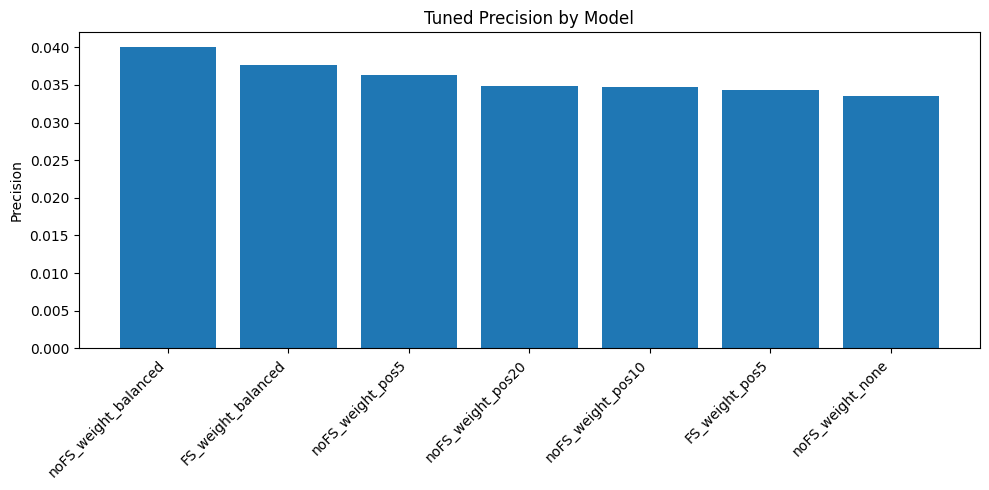

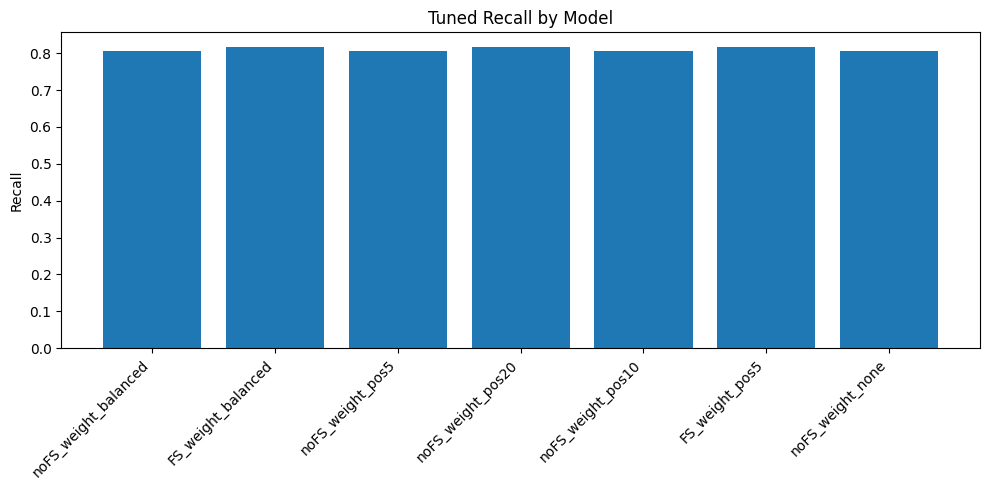

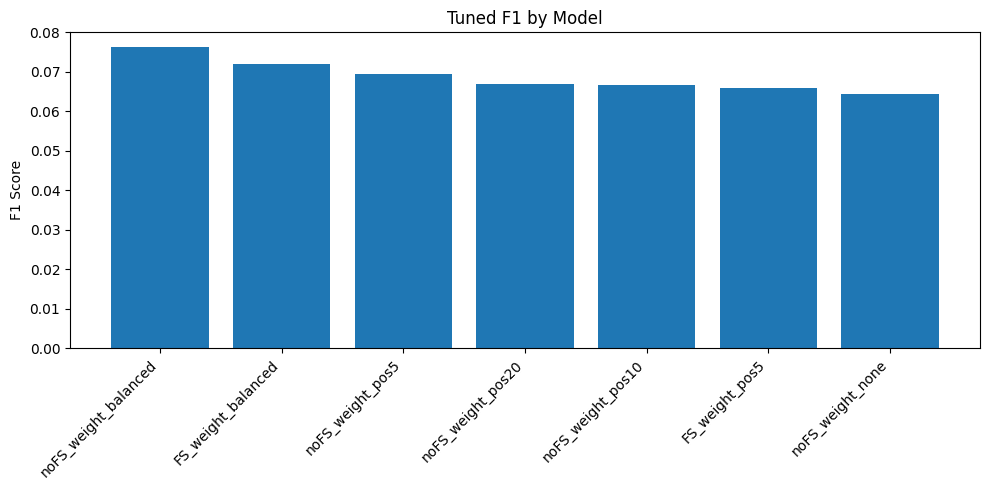

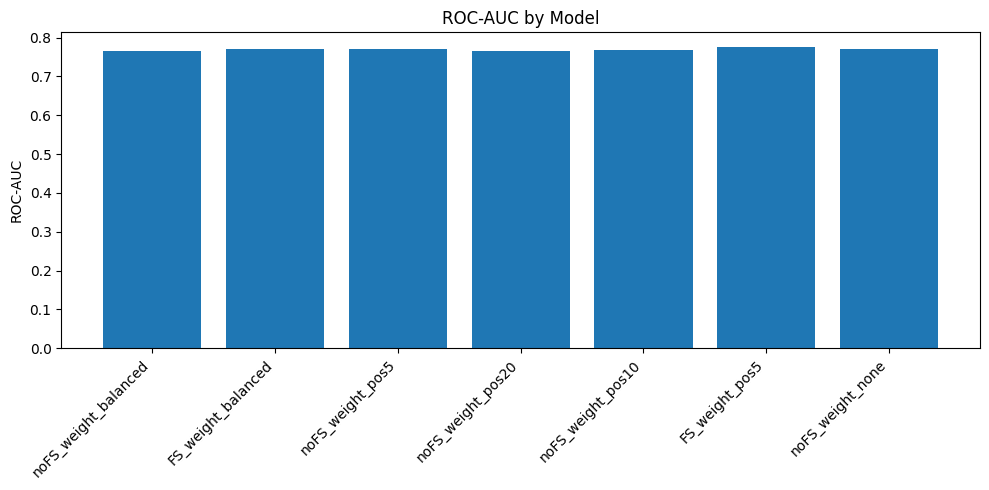

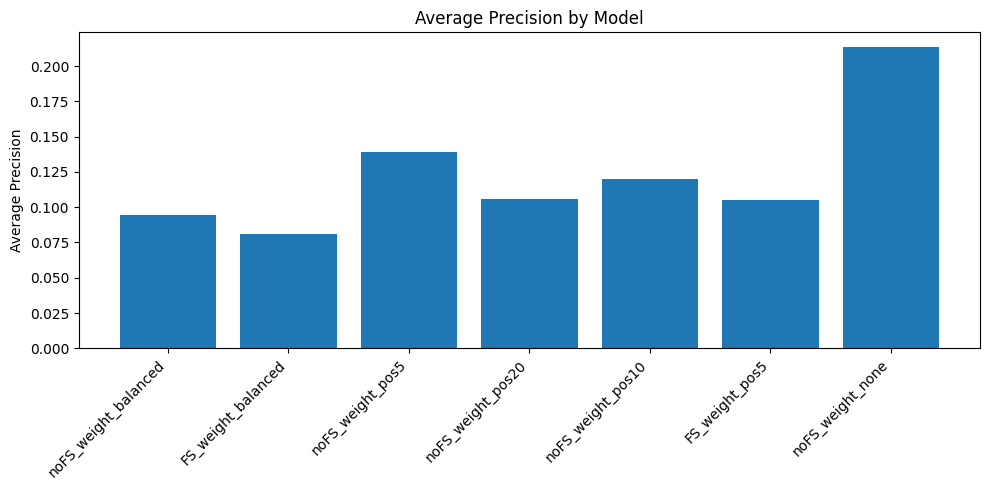

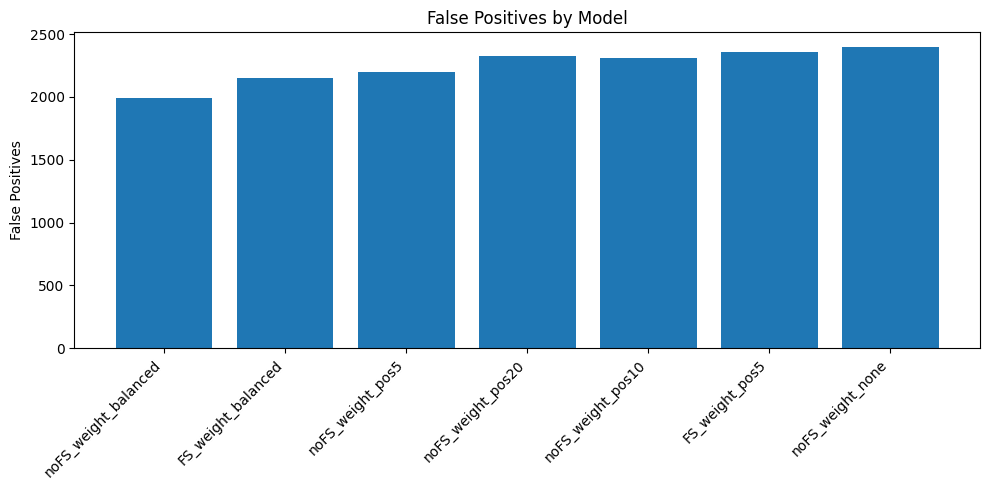

In [ ]:
# =========================================================
# B) COMPARISON CHARTS FROM SUMMARY TABLE
# =========================================================

import matplotlib.pyplot as plt

plot_df = summary_df.copy()

# Precision comparison
plt.figure(figsize=(10, 5))
plt.bar(plot_df["model"], plot_df["precision"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Precision")
plt.title("Tuned Precision by Model")
plt.tight_layout()
plt.show()

# Recall comparison
plt.figure(figsize=(10, 5))
plt.bar(plot_df["model"], plot_df["recall"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Recall")
plt.title("Tuned Recall by Model")
plt.tight_layout()
plt.show()

# F1 comparison
plt.figure(figsize=(10, 5))
plt.bar(plot_df["model"], plot_df["f1"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("F1 Score")
plt.title("Tuned F1 by Model")
plt.tight_layout()
plt.show()

# ROC-AUC comparison
plt.figure(figsize=(10, 5))
plt.bar(plot_df["model"], plot_df["roc_auc"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("ROC-AUC")
plt.title("ROC-AUC by Model")
plt.tight_layout()
plt.show()

# Average precision comparison
plt.figure(figsize=(10, 5))
plt.bar(plot_df["model"], plot_df["avg_precision"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Average Precision")
plt.title("Average Precision by Model")
plt.tight_layout()
plt.show()

# False positives comparison
plt.figure(figsize=(10, 5))
plt.bar(plot_df["model"], plot_df["fp"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("False Positives")
plt.title("False Positives by Model")
plt.tight_layout()
plt.show()

In [ ]:
# =========================================================
# C) PLOT TRUE ROC / PR / CONFUSION FROM all_results IF AVAILABLE
# =========================================================

import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

if "all_results" not in globals() or len(all_results) == 0:
    print("all_results is missing or empty. Skip to Block D to rerun selected models.")
else:
    valid_results = [
        r for r in all_results
        if isinstance(r, dict)
        and "y_true" in r
        and "y_prob" in r
        and "chosen_threshold" in r
        and "tuned_metrics" in r
    ]

    print("Valid results found in memory:", [r["name"] for r in valid_results])

    # ROC curves
    plt.figure(figsize=(9, 7))
    for r in valid_results:
        fpr, tpr, _ = roc_curve(r["y_true"], r["y_prob"])
        auc = roc_auc_score(r["y_true"], r["y_prob"])
        plt.plot(fpr, tpr, label=f'{r["name"]} (AUC={auc:.3f})')
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # PR curves
    plt.figure(figsize=(9, 7))
    for r in valid_results:
        precisions, recalls, _ = precision_recall_curve(r["y_true"], r["y_prob"])
        ap = average_precision_score(r["y_true"], r["y_prob"])
        plt.plot(recalls, precisions, label=f'{r["name"]} (AP={ap:.3f})')
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curves")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Best model confusion matrix
    best_name = summary_df.iloc[0]["model"]
    best_matches = [r for r in valid_results if r["name"] == best_name]

    if len(best_matches) == 0:
        print(f"{best_name} not found in in-memory all_results. Use Block D.")
    else:
        best_result = best_matches[0]
        y_pred = best_result["tuned_metrics"]["y_pred"]

        cm = confusion_matrix(best_result["y_true"], y_pred)
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=["Non-Senolytic", "Senolytic"]
        )
        disp.plot(cmap="Blues")
        plt.title(f"Confusion Matrix: {best_name}")
        plt.show()

        cm_norm = confusion_matrix(best_result["y_true"], y_pred, normalize="true")
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm_norm,
            display_labels=["Non-Senolytic", "Senolytic"]
        )
        disp.plot(cmap="Blues", values_format=".2f")
        plt.title(f"Normalized Confusion Matrix: {best_name}")
        plt.show()

all_results is missing or empty. Skip to Block D to rerun selected models.


In [ ]:
# =========================================================
# RELOAD DATA → DEFINE X and y
# =========================================================

import pandas as pd
from scipy.io import arff

# -------------------------------
# Upload file (Colab)
# -------------------------------
try:
    from google.colab import files
    uploaded = files.upload()
    ARFF_FILE = list(uploaded.keys())[0]
except:
    # If not in Colab, set your file path manually here
    ARFF_FILE = "your_file.arff"  # <-- change this if needed

# -------------------------------
# Load ARFF
# -------------------------------
data, meta = arff.loadarff(ARFF_FILE)
df = pd.DataFrame(data)

# -------------------------------
# Process target
# -------------------------------
TARGET_COL = "senolytic"
df[TARGET_COL] = df[TARGET_COL].str.decode("utf-8").astype(int)

# -------------------------------
# Create X and y
# -------------------------------
X = df.drop(columns=[TARGET_COL]).copy()
y = df[TARGET_COL].copy()

# -------------------------------
# Sanity check
# -------------------------------
print("Data loaded successfully")
print("Shape:", df.shape)
print("Positive count:", int(y.sum()))
print("Negative count:", int((y == 0).sum()))
print("Positive rate:", y.mean())

Saving input_data_no_smiles.arff to input_data_no_smiles.arff
Data loaded successfully
Shape: (4866, 201)
Positive count: 103
Negative count: 4763
Positive rate: 0.02116728318947801


Starting LOOCV for noFS_weight_balanced (4866 folds)
Completed fold 50/4866 | Elapsed: 0.5 min
Completed fold 100/4866 | Elapsed: 1.3 min
Completed fold 150/4866 | Elapsed: 1.9 min
Completed fold 200/4866 | Elapsed: 2.5 min
Completed fold 250/4866 | Elapsed: 3.0 min
Completed fold 300/4866 | Elapsed: 3.6 min
Completed fold 350/4866 | Elapsed: 4.2 min
Completed fold 400/4866 | Elapsed: 4.8 min
Completed fold 450/4866 | Elapsed: 5.4 min
Completed fold 500/4866 | Elapsed: 5.9 min
Completed fold 550/4866 | Elapsed: 6.5 min
Completed fold 600/4866 | Elapsed: 7.0 min
Completed fold 650/4866 | Elapsed: 7.6 min
Completed fold 700/4866 | Elapsed: 8.2 min
Completed fold 750/4866 | Elapsed: 8.8 min
Completed fold 800/4866 | Elapsed: 9.3 min
Completed fold 850/4866 | Elapsed: 9.9 min
Completed fold 900/4866 | Elapsed: 10.5 min
Completed fold 950/4866 | Elapsed: 11.1 min
Completed fold 1000/4866 | Elapsed: 11.7 min
Completed fold 1050/4866 | Elapsed: 12.3 min
Completed fold 1100/4866 | Elapsed: 12.

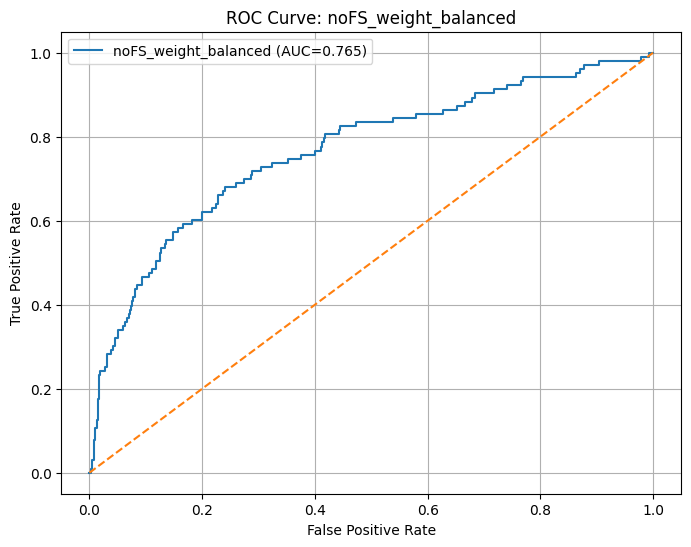

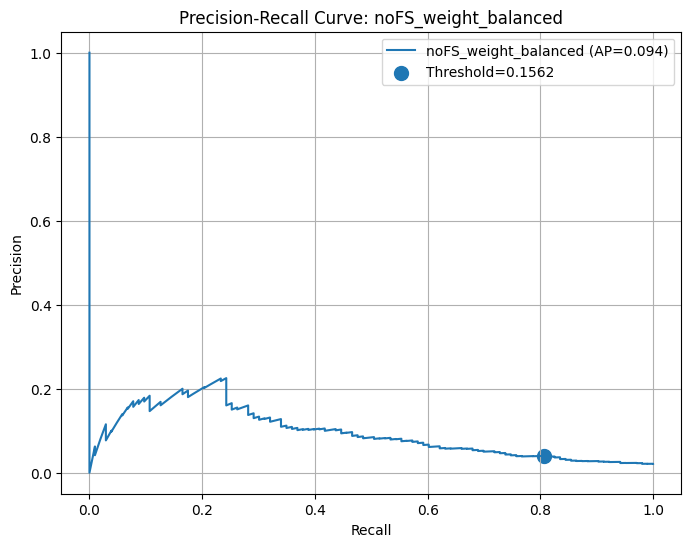

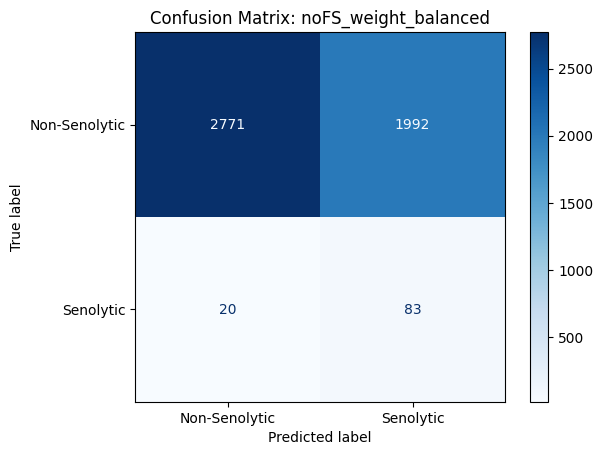

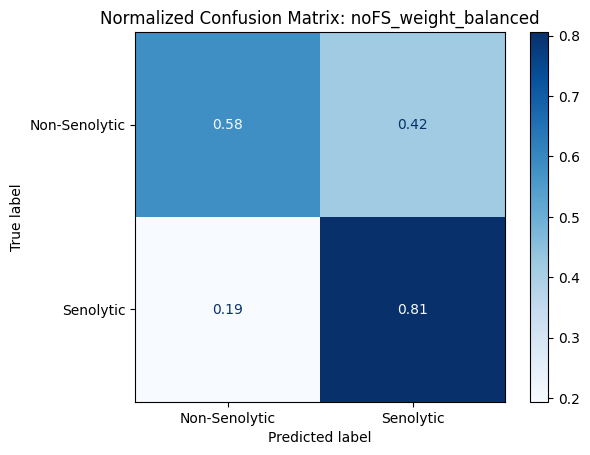

In [ ]:
# =========================================================
# FINAL PLOTS FOR BEST MODEL ONLY: noFS_weight_balanced
# =========================================================

import time
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score,
    roc_curve, roc_auc_score
)

try:
    from imblearn.pipeline import Pipeline as ImbPipeline
except ModuleNotFoundError:
    from sklearn.pipeline import Pipeline as ImbPipeline

# -------------------------------
# CHECK THAT X AND y EXIST
# -------------------------------
if "X" not in globals() or "y" not in globals():
    raise NameError("X and y are not defined. Reload your dataset first.")

TARGET_RECALL = 0.80

# -------------------------------
# Helper functions
# -------------------------------
def make_pipeline(class_weight="balanced", C=0.1, max_iter=5000):
    steps = [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=C,
            class_weight=class_weight,
            solver="liblinear",
            max_iter=max_iter
        ))
    ]
    return ImbPipeline(steps)

def run_loocv_probabilities(X, y, pipeline, verbose_every=50):
    loo = LeaveOneOut()
    y_true_all = []
    y_prob_all = []

    total_folds = len(X)
    start_time = time.time()

    print(f"Starting LOOCV for noFS_weight_balanced ({total_folds} folds)")

    for fold_idx, (train_idx, test_idx) in enumerate(loo.split(X), start=1):
        X_train = X.iloc[train_idx]
        X_test  = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test  = y.iloc[test_idx]

        pipeline.fit(X_train, y_train)
        prob = pipeline.predict_proba(X_test)[:, 1][0]

        y_true_all.append(int(y_test.iloc[0]))
        y_prob_all.append(float(prob))

        if fold_idx % verbose_every == 0 or fold_idx == total_folds:
            elapsed = (time.time() - start_time) / 60
            print(f"Completed fold {fold_idx}/{total_folds} | Elapsed: {elapsed:.1f} min")

    print("Finished LOOCV\n")
    return np.array(y_true_all), np.array(y_prob_all)

def threshold_for_target_recall(y_true, y_prob, target_recall=0.80):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)

    precisions_t = precisions[:-1]
    recalls_t = recalls[:-1]

    valid = np.where(recalls_t >= target_recall)[0]
    if len(valid) == 0:
        return None

    best_idx = valid[np.argmax(precisions_t[valid])]
    return {
        "threshold": thresholds[best_idx],
        "precision": precisions_t[best_idx],
        "recall": recalls_t[best_idx]
    }

def evaluate_at_threshold(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "avg_precision": average_precision_score(y_true, y_prob),
        "cm": confusion_matrix(y_true, y_pred),
        "y_pred": y_pred
    }

# -------------------------------
# Run best model
# -------------------------------
pipe = make_pipeline(class_weight="balanced", C=0.1)

y_true_best, y_prob_best = run_loocv_probabilities(X, y, pipe, verbose_every=50)

chosen = threshold_for_target_recall(
    y_true_best,
    y_prob_best,
    target_recall=TARGET_RECALL
)

best_threshold = 0.5 if chosen is None else chosen["threshold"]
best_metrics = evaluate_at_threshold(y_true_best, y_prob_best, best_threshold)

print("Chosen threshold:", round(best_threshold, 6))
print("Precision:", round(best_metrics["precision"], 4))
print("Recall:   ", round(best_metrics["recall"], 4))
print("F1:       ", round(best_metrics["f1"], 4))
print("ROC-AUC:  ", round(best_metrics["roc_auc"], 4))
print("AP:       ", round(best_metrics["avg_precision"], 4))
print("Confusion Matrix:")
print(best_metrics["cm"])

# -------------------------------
# ROC curve
# -------------------------------
fpr, tpr, _ = roc_curve(y_true_best, y_prob_best)
auc = roc_auc_score(y_true_best, y_prob_best)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'noFS_weight_balanced (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: noFS_weight_balanced")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# Precision-Recall curve
# -------------------------------
precisions, recalls, thresholds = precision_recall_curve(y_true_best, y_prob_best)
ap = average_precision_score(y_true_best, y_prob_best)

plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, label=f'noFS_weight_balanced (AP={ap:.3f})')

if len(thresholds) > 0:
    idx = np.argmin(np.abs(thresholds - best_threshold))
    idx = min(idx, len(precisions) - 2)
    plt.scatter(recalls[idx], precisions[idx], s=100, label=f"Threshold={best_threshold:.4f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve: noFS_weight_balanced")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# Confusion matrix
# -------------------------------
disp = ConfusionMatrixDisplay(
    confusion_matrix=best_metrics["cm"],
    display_labels=["Non-Senolytic", "Senolytic"]
)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix: noFS_weight_balanced")
plt.show()

# -------------------------------
# Normalized confusion matrix
# -------------------------------
cm_norm = confusion_matrix(y_true_best, best_metrics["y_pred"], normalize="true")
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=["Non-Senolytic", "Senolytic"]
)
disp.plot(cmap="Blues", values_format=".2f")
plt.title("Normalized Confusion Matrix: noFS_weight_balanced")
plt.show()

In [ ]:
# =========================================================
# SAVE BEST MODEL METRICS
# =========================================================

best_model_summary = pd.DataFrame([{
    "model": "noFS_weight_balanced",
    "threshold": best_threshold,
    "precision": best_metrics["precision"],
    "recall": best_metrics["recall"],
    "f1": best_metrics["f1"],
    "accuracy": best_metrics["accuracy"],
    "roc_auc": best_metrics["roc_auc"],
    "avg_precision": best_metrics["avg_precision"],
    "tn": int(best_metrics["cm"][0, 0]),
    "fp": int(best_metrics["cm"][0, 1]),
    "fn": int(best_metrics["cm"][1, 0]),
    "tp": int(best_metrics["cm"][1, 1]),
}])

print(best_model_summary)
best_model_summary.to_csv("best_model_summary.csv", index=False)
print("Saved: best_model_summary.csv")

                  model  threshold  precision    recall        f1  accuracy  \
0  noFS_weight_balanced   0.156214       0.04  0.805825  0.076217  0.586519   

   roc_auc  avg_precision    tn    fp  fn  tp  
0  0.76548       0.094386  2771  1992  20  83  
Saved: best_model_summary.csv


In [ ]:
# =========================================================
# SAVE OUT-OF-FOLD PREDICTIONS
# =========================================================

best_oof_df = pd.DataFrame({
    "y_true": y_true_best,
    "y_prob": y_prob_best,
    "y_pred": best_metrics["y_pred"]
})

print(best_oof_df.head())
best_oof_df.to_csv("best_model_oof_predictions.csv", index=False)
print("Saved: best_model_oof_predictions.csv")

   y_true    y_prob  y_pred
0       0  0.296404       1
1       0  0.037676       0
2       0  0.054463       0
3       0  0.099491       0
4       0  0.001748       0
Saved: best_model_oof_predictions.csv


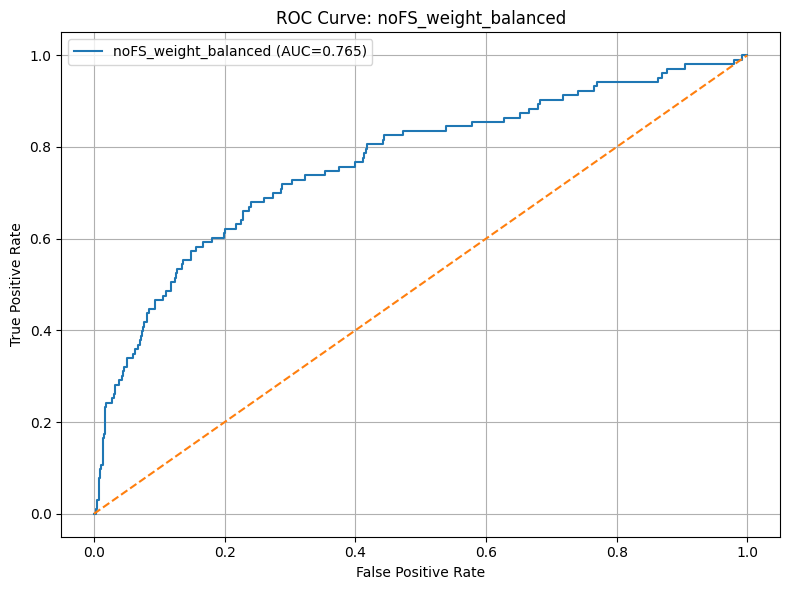

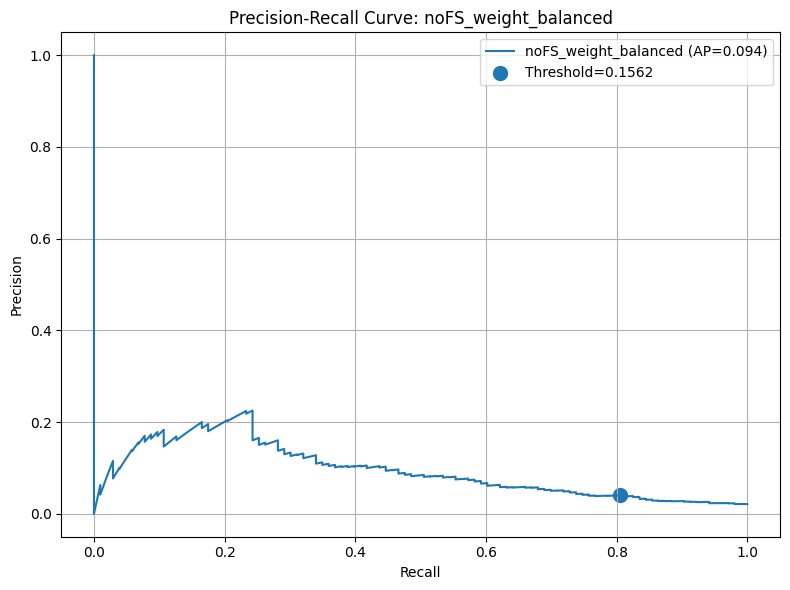

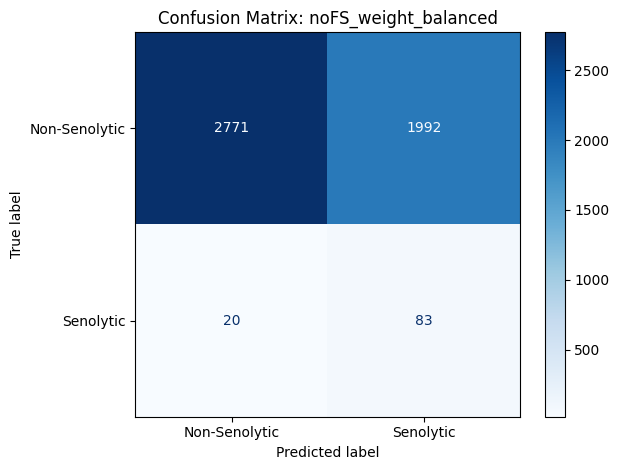

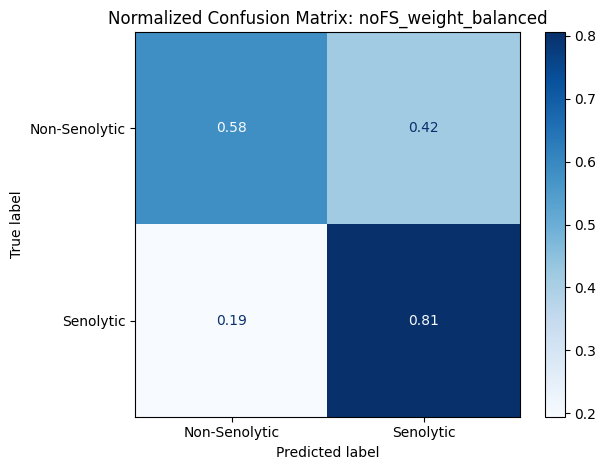

Saved all plot PNGs.


In [ ]:
# =========================================================
# SAVE PLOTS
# =========================================================

# ROC
fpr, tpr, _ = roc_curve(y_true_best, y_prob_best)
auc = roc_auc_score(y_true_best, y_prob_best)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'noFS_weight_balanced (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: noFS_weight_balanced")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("roc_curve_best_model.png", dpi=300, bbox_inches="tight")
plt.show()

# PR
precisions, recalls, thresholds = precision_recall_curve(y_true_best, y_prob_best)
ap = average_precision_score(y_true_best, y_prob_best)

plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, label=f'noFS_weight_balanced (AP={ap:.3f})')

if len(thresholds) > 0:
    idx = np.argmin(np.abs(thresholds - best_threshold))
    idx = min(idx, len(precisions) - 2)
    plt.scatter(recalls[idx], precisions[idx], s=100, label=f"Threshold={best_threshold:.4f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve: noFS_weight_balanced")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("pr_curve_best_model.png", dpi=300, bbox_inches="tight")
plt.show()

# Confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=best_metrics["cm"],
    display_labels=["Non-Senolytic", "Senolytic"]
)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix: noFS_weight_balanced")
plt.tight_layout()
plt.savefig("confusion_matrix_best_model.png", dpi=300, bbox_inches="tight")
plt.show()

# Normalized confusion matrix
cm_norm = confusion_matrix(y_true_best, best_metrics["y_pred"], normalize="true")
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=["Non-Senolytic", "Senolytic"]
)
disp.plot(cmap="Blues", values_format=".2f")
plt.title("Normalized Confusion Matrix: noFS_weight_balanced")
plt.tight_layout()
plt.savefig("confusion_matrix_best_model_normalized.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved all plot PNGs.")

In [ ]:
# =========================================================
# SAVE MODEL COMPARISON TABLE
# =========================================================

if "summary_df" in globals():
    summary_df.to_csv("all_model_results_summary.csv", index=False)
    print("Saved: all_model_results_summary.csv")
else:
    print("summary_df not found — skip this block.")

Saved: all_model_results_summary.csv


In [ ]:
# =========================================================
# FINAL MODEL + METHODOLOGY SUMMARY (FULL EXPLANATION)
# =========================================================

print("="*90)
print("FINAL MODEL, METHODOLOGY, AND RESULTS SUMMARY")
print("="*90)

print("\n🏆 BEST MODEL:")
print("→ Logistic Regression (no feature selection) with class_weight='balanced'")

print("\n📊 KEY RESULTS:")
print(f"Precision : {best_metrics['precision']:.4f}")
print(f"Recall    : {best_metrics['recall']:.4f}")
print(f"F1 Score  : {best_metrics['f1']:.4f}")
print(f"ROC-AUC   : {best_metrics['roc_auc']:.4f}")
print(f"Avg Prec. : {best_metrics['avg_precision']:.4f}")

cm = best_metrics["cm"]
print("\nConfusion Matrix:")
print(f"TN: {cm[0,0]} | FP: {cm[0,1]}")
print(f"FN: {cm[1,0]} | TP: {cm[1,1]}")

# =========================================================
# METHODOLOGY
# =========================================================
print("\n" + "-"*90)
print("METHODOLOGY")
print("-"*90)

print("\n1. Class Imbalance:")
print("The dataset is highly imbalanced (~2% positive senolytic compounds).")
print("This makes accuracy misleading and requires specialized handling.")

print("\n2. Cost-Sensitive Learning:")
print("Class weights were used to penalize mistakes on the minority class more heavily.")
print("The 'balanced' setting automatically scales weights based on class frequency,")
print("ensuring the model prioritizes identifying senolytic compounds.")

print("\n3. Feature Selection:")
print("Random Forest-based feature selection was tested to reduce dimensionality.")
print("However, it did not improve performance and slightly reduced precision.")
print("This suggests useful signal is distributed across many features rather than a small subset.")

print("\n4. Parameter Tuning:")
print("Regularization strength (C) was fixed at 0.1 to isolate the impact of cost-sensitive learning.")
print("Different class weight configurations (None, balanced, pos5, pos10, pos20) were compared.")

print("\n5. Cross-Validation Strategy:")
print("Leave-One-Out Cross-Validation (LOOCV) was used for evaluation.")
print("This provides a highly robust estimate by training on nearly the entire dataset each time.")

print("\n6. Threshold Tuning:")
print("Instead of using a default threshold (0.5), the threshold was tuned to:")
print("→ Achieve recall ≥ 0.80")
print("→ Then maximize precision among those thresholds")
print("This ensures the model prioritizes minimizing false negatives.")

# =========================================================
# MODEL BEHAVIOR
# =========================================================
print("\n" + "-"*90)
print("MODEL BEHAVIOR AND INTERPRETATION")
print("-"*90)

print("\nPrecision-Recall Tradeoff:")
print("Due to extreme class imbalance, increasing recall leads to more false positives.")
print("The model intentionally sacrifices precision to ensure most senolytic compounds are detected.")

print("\nConfusion Matrix Insight:")
print("- False negatives are low → critical objective achieved")
print("- False positives are high → expected tradeoff in imbalanced settings")

print("\nCost-Sensitive Learning Insight:")
print("Balanced class weighting performed best.")
print("Increasing weights beyond this (pos10, pos20) led to more false positives without improving recall.")
print("This demonstrates diminishing returns from aggressive cost penalization.")

print("\nFeature Selection Insight:")
print("Feature selection did not improve results, indicating:")
print("- Signal is likely spread across many features")
print("- Removing features may remove useful weak predictors")

# =========================================================
# CURVES INTERPRETATION
# =========================================================
print("\n" + "-"*90)
print("CURVE INTERPRETATION")
print("-"*90)

print("\nROC Curve:")
print("The ROC curve shows an AUC around 0.77, indicating the model can distinguish")
print("between classes significantly better than random guessing (AUC = 0.5).")

print("\nPrecision-Recall Curve:")
print("The PR curve is more informative for this imbalanced problem.")
print("It shows the tradeoff between precision and recall across thresholds.")
print("The selected threshold is marked where recall ≥ 0.80 and precision is maximized.")

# =========================================================
# FINAL CONCLUSION
# =========================================================
print("\n" + "-"*90)
print("FINAL CONCLUSION")
print("-"*90)

print("\nThe final model successfully identifies the majority of senolytic compounds")
print("(recall ≥ 0.80) while maintaining better-than-random precision.")

print("\nAlthough precision remains low, this is expected due to extreme class imbalance.")
print("The model demonstrates meaningful predictive ability and effectively balances")
print("the tradeoff between false negatives and false positives.")

print("\nOverall, cost-sensitive learning combined with threshold tuning proved to be")
print("the most effective strategy for this problem.")
print("="*90)

FINAL MODEL, METHODOLOGY, AND RESULTS SUMMARY

🏆 BEST MODEL:
→ Logistic Regression (no feature selection) with class_weight='balanced'

📊 KEY RESULTS:
Precision : 0.0400
Recall    : 0.8058
F1 Score  : 0.0762
ROC-AUC   : 0.7655
Avg Prec. : 0.0944

Confusion Matrix:
TN: 2771 | FP: 1992
FN: 20 | TP: 83

------------------------------------------------------------------------------------------
METHODOLOGY
------------------------------------------------------------------------------------------

1. Class Imbalance:
The dataset is highly imbalanced (~2% positive senolytic compounds).
This makes accuracy misleading and requires specialized handling.

2. Cost-Sensitive Learning:
Class weights were used to penalize mistakes on the minority class more heavily.
The 'balanced' setting automatically scales weights based on class frequency,
ensuring the model prioritizes identifying senolytic compounds.

3. Feature Selection:
Random Forest-based feature selection was tested to reduce dimensionality

In [ ]:
# =========================================================
# FULL METRICS (ALL CLASSES, NO RERUN)
# =========================================================

from sklearn.metrics import classification_report

print("="*60)
print("FULL CLASSIFICATION REPORT")
print("="*60)

print(classification_report(
    y_true_best,
    best_metrics["y_pred"],
    target_names=["Non-Senolytic (0)", "Senolytic (1)"],
    digits=4
))

FULL CLASSIFICATION REPORT
                   precision    recall  f1-score   support

Non-Senolytic (0)     0.9928    0.5818    0.7337      4763
    Senolytic (1)     0.0400    0.8058    0.0762       103

         accuracy                         0.5865      4866
        macro avg     0.5164    0.6938    0.4049      4866
     weighted avg     0.9727    0.5865    0.7197      4866

